In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "font.size":        10,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "axes.grid":        False,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "axes.linewidth":   0.6,
    "lines.linewidth":  0.9,
    "legend.frameon":   False,
    "legend.fontsize":  9,
})

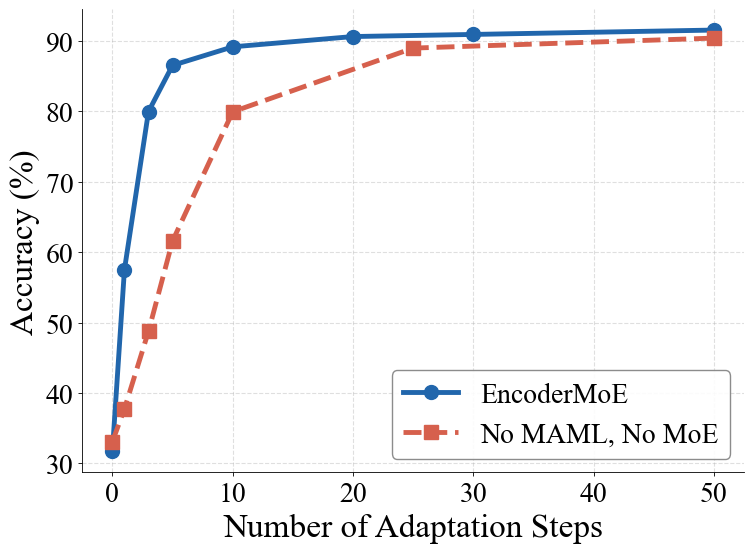

In [14]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- Data ---
M0_eval_sweep_dict = {0: 31.72, 1: 57.50, 3: 79.95, 5: 86.50, 10: 89.13, 20: 90.59, 30: 90.89, 50: 91.51}
A2_eval_sweep_dict = {0: 33.10, 1: 37.74, 3: 48.76, 5: 61.58, 10: 79.91, 25: 88.95, 50: 90.37}

# --- Style ---
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 22,
    "axes.titlesize": 24,
    "axes.labelsize": 24,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "lines.linewidth": 3.5,
    "lines.markersize": 10,
})

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    list(M0_eval_sweep_dict.keys()),
    list(M0_eval_sweep_dict.values()),
    label="EncoderMoE",
    marker="o",
    color="#2166ac",
)
ax.plot(
    list(A2_eval_sweep_dict.keys()),
    list(A2_eval_sweep_dict.values()),
    label="No MAML, No MoE",
    marker="s",
    linestyle="--",
    color="#d6604d",
)

ax.set_xlabel("Number of Adaptation Steps")
ax.set_ylabel("Accuracy (%)")
ax.legend(frameon=True, framealpha=0.9, edgecolor="gray")
ax.grid(True, linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.savefig("eval_steps_sweep.pdf", bbox_inches="tight", dpi=500)
plt.show()

In [4]:
import json
import pandas as pd
from pathlib import Path

# ── Subject constants ──────────────────────────────────────────────────────────
# All 32 subjects seen across the L2SO folds (sorted for stable column ordering).
ALL_SUBJECTS = [
    'P004', 'P005', 'P006', 'P008', 'P010', 'P011',
    'P102', 'P103', 'P104', 'P105', 'P106', 'P107', 'P108', 'P109', 'P110',
    'P111', 'P112', 'P114', 'P115', 'P116', 'P118', 'P119', 'P121', 'P122',
    'P123', 'P124', 'P125', 'P126', 'P127', 'P128', 'P131', 'P132',
]

# The 4 subjects previously highlighted in figures — still used for scatter dots.
HIGHLIGHT_SUBJECTS = ['P004', 'P104', 'P105', 'P121']


# ── Row builder ────────────────────────────────────────────────────────────────

def make_row_l2so(ablation_id: str, ft_label: str, per_subject_accs: dict) -> dict:
    """
    per_subject_accs: {PID -> accuracy} covering all 32 L2SO test subjects.
    Mean/Std are cross-subject statistics (one scalar per subject per fold;
    no within-subject repeated measurements in the current setup, so std
    reflects identity-level variance, not measurement noise).
    """
    accs = pd.Series(list(per_subject_accs.values()))
    return {
        'Ablation_ID':     ablation_id,
        'Finetune_Method': ft_label,
        **per_subject_accs,          # one column per PID
        'Mean':   accs.mean(),
        'Median': accs.median(),
        'Q25':    accs.quantile(0.25),
        'Q75':    accs.quantile(0.75),
        'Std':    accs.std(),
    }


# ── Per-ablation parsers ───────────────────────────────────────────────────────

def parse_l2so_fold_results(data: dict, ablation_id: str) -> list[dict]:
    """
    For ablations that store a list of per-fold dicts in a single summary JSON
    (A2, A11, and future ablations with the same schema).

    Each fold tests exactly one subject; we collect per_user_acc across all folds
    to build {PID -> acc}, then emit one row per ft_mode (head / full).

    Note: test_PID is a list in A2 but a plain string in A11 — we ignore it and
    always source the PID from the per_user_acc key.
    """
    head_accs: dict = {}
    full_accs: dict = {}
    maml_accs: dict = {}

    if ablation_id in ["A1", "A2", "A7", "A11"]:  # NON-MAML
        for fold in data['fold_results']:
            head_accs.update(fold['test_head_only']['per_user_acc'])
            full_accs.update(fold['test_full_ft']['per_user_acc'])
        assert set(head_accs.keys()) == set(full_accs.keys()), \
            f"{ablation_id}: head and full ft subject sets differ"
        return [
            make_row_l2so(ablation_id, 'head', head_accs),
            make_row_l2so(ablation_id, 'full', full_accs),
        ]
    elif ablation_id in ["A4"]:  # MAML
        for fold in data['fold_results']:
            maml_accs.update(fold['test_results']['per_user_acc'])
        return [
            make_row_l2so(ablation_id, 'MAML', maml_accs),
        ]
    else:
        raise ValueError(f"parse_l2so_fold_results: unhandled ablation_id '{ablation_id}'")


def parse_l2so_all_results_flat(data: dict, ablation_id: str) -> list[dict]:
    """
    For ablations (e.g. A8) whose JSON stores results as a flat list in
    'all_results', where each entry is one subject's record with keys:
        pid, mean_acc, ...

    The top-level 'per_subject_mean' dict {PID -> acc} is already aggregated,
    so we read that directly rather than re-deriving it from all_results.
    """
    per_subject_mean = data['per_subject_mean']  # {PID -> float}

    assert set(per_subject_mean.keys()) == {r['pid'] for r in data['all_results']}, \
        f"{ablation_id}: PIDs in per_subject_mean and all_results do not match"

    return [
        make_row_l2so(ablation_id, 'MAML', per_subject_mean),
    ]


def parse_l2so_per_subject_top_level(data: dict, ablation_id: str) -> list[dict]:
    """
    For ablations that pre-aggregate at top level (A7):
    per_subject_head_acc / per_subject_full_acc dicts are already complete.
    """
    return [
        make_row_l2so(ablation_id, 'head', data['per_subject_head_acc']),
        make_row_l2so(ablation_id, 'full', data['per_subject_full_acc']),
    ]


def parse_l2so_m0_per_fold_folder(folder: Path) -> list[dict]:
    """
    M0 (MAML + MoE) was run as one job per fold, so there is no single summary
    JSON — instead there are 32 per-fold files, each named:
        M0_<timestamp>_fold<NN>_summary_results.json

    Schema per file:
        fold_result.test_results.per_user_acc -> {PID: acc}  (one PID per fold)

    We collect all 32 and assemble a single {PID -> acc} dict, then emit one
    row with ft_label='MAML'.
    """
    fold_files = sorted(folder.glob("M0_*_fold*_summary_results.json"))
    assert fold_files, f"No M0 fold JSONs found in {folder}"

    per_subject_accs: dict = {}

    for fp in fold_files:
        with open(fp) as f:
            data = json.load(f)

        assert data['ablation_id'] == 'M0', \
            f"{fp.name}: expected ablation_id='M0', got '{data['ablation_id']}'"
        assert data['test_procedure'] == 'L2SO', \
            f"{fp.name}: expected test_procedure='L2SO', got '{data['test_procedure']}'"

        fold_result = data['fold_result']   # singular — one fold per file
        per_subject_accs.update(fold_result['test_results']['per_user_acc'])

    assert len(per_subject_accs) == len(fold_files), (
        f"M0: collected {len(per_subject_accs)} unique PIDs from {len(fold_files)} files — "
        f"expected them to match. Possible duplicate or missing fold."
    )

    return [make_row_l2so('M0', 'MAML', per_subject_accs)]


# ── Top-level loader ───────────────────────────────────────────────────────────

def load_l2so_folder(folder: Path, m0_folder: Path | None = None) -> pd.DataFrame:
    """
    Load all L2SO summary JSONs from `folder` and return a tidy DataFrame.
    Columns: Ablation_ID, Finetune_Method, <one col per PID>, Mean, Std.

    M0 is handled separately because it saves one JSON per fold rather than
    one summary JSON for the whole ablation. Pass m0_folder pointing at the
    directory containing all 32 M0 fold JSONs (e.g. M0_collected_jsons/).
    If m0_folder is None, M0 is skipped with a warning.
    """
    rows = []

    for json_file in sorted(folder.glob("*_summary_results.json")):
        with open(json_file) as f:
            data = json.load(f)

        assert data['test_procedure'] == 'L2SO', (
            f"{json_file.name}: expected test_procedure='L2SO', "
            f"got '{data['test_procedure']}'"
        )

        ablation_id = data['ablation_id']
        #print(f"ablation_id: {ablation_id}")

        if 'fold_results' in data:
            rows.extend(parse_l2so_fold_results(data, ablation_id))
        elif 'per_subject_head_acc' in data and 'per_subject_full_acc' in data:
            rows.extend(parse_l2so_per_subject_top_level(data, ablation_id))
        elif 'all_results' in data and 'per_subject_mean' in data:  # A8-style flat schema
            rows.extend(parse_l2so_all_results_flat(data, ablation_id))
        else:
            raise ValueError(
                f"{json_file.name} (ablation {ablation_id}): unrecognised schema — "
                f"has neither 'fold_results' nor 'per_subject_head/full_acc' nor "
                f"'all_results'+'per_subject_mean'. "
                f"Top-level keys: {list(data.keys())}"
            )

    # M0 lives in its own folder of per-fold files
    if m0_folder is not None:
        rows.extend(parse_l2so_m0_per_fold_folder(m0_folder))
    else:
        print("WARNING: m0_folder not provided — M0 will be absent from df_l2so.")

    assert rows, f"No valid JSON files found in {folder}"

    cols = ['Ablation_ID', 'Finetune_Method'] + ALL_SUBJECTS + ['Mean', 'Median', 'Q25', 'Q75', 'Std']
    return pd.DataFrame(rows, columns=cols)

In [5]:
# ── Load ───────────────────────────────────────────────────────────────────────
FOLDER_L2SO = Path(r"C:\Users\kdmen\OneDrive\Desktop\Spring26\MAML_MOE_NeurIPS26\raw_results\paper_l2so_jsons")
M0_FOLDER   = Path(r"C:\Users\kdmen\OneDrive\Desktop\Spring26\MAML_MOE_NeurIPS26\raw_results\paper_L2SO_jsons\M0_collected_jsons")

df = load_l2so_folder(FOLDER_L2SO, m0_folder=M0_FOLDER)
print(df.shape)
print(df.columns)
df.head()

(11, 39)
Index(['Ablation_ID', 'Finetune_Method', 'P004', 'P005', 'P006', 'P008',
       'P010', 'P011', 'P102', 'P103', 'P104', 'P105', 'P106', 'P107', 'P108',
       'P109', 'P110', 'P111', 'P112', 'P114', 'P115', 'P116', 'P118', 'P119',
       'P121', 'P122', 'P123', 'P124', 'P125', 'P126', 'P127', 'P128', 'P131',
       'P132', 'Mean', 'Median', 'Q25', 'Q75', 'Std'],
      dtype='object')


,Ablation_ID,Finetune_Method,P004,P005,P006,P008,P010,P011,P102,P103,...,P126,P127,P128,P131,P132,Mean,Median,Q25,Q75,Std
0,A11,head,0.630741,0.734963,0.713778,0.607407,0.698815,0.593556,0.555481,0.706889,...,0.736444,0.532741,0.774074,0.430519,0.563111,0.621574,0.608111,0.564278,0.708611,0.098185
1,A11,full,0.551926,0.632444,0.652222,0.625852,0.650963,0.535778,0.415185,0.590148,...,0.711481,0.472222,0.695926,0.442000,0.539630,0.560299,0.566333,0.471519,0.633222,0.102607
2,A1,head,0.676741,0.652148,0.669407,0.710667,0.748815,0.619556,0.644296,0.476148,...,0.694593,0.515259,0.425185,0.603556,0.487630,0.575354,0.600926,0.484759,0.657130,0.109124
3,A1,full,0.845407,0.812815,0.877926,0.705111,0.819481,0.752444,0.861259,0.886815,...,0.789111,0.731630,0.762963,0.697556,0.753111,0.768537,0.763000,0.726870,0.824019,0.086425
4,A2,head,0.489333,0.446074,0.544519,0.717185,0.721037,0.681111,0.472074,0.478148,...,0.646519,0.443778,0.481111,0.488074,0.376667,0.524502,0.490074,0.438056,0.621000,0.109404


In [6]:
print(df[['Ablation_ID', 'Finetune_Method']].to_string())

   Ablation_ID Finetune_Method
0          A11            head
1          A11            full
2           A1            head
3           A1            full
4           A2            head
5           A2            full
6           A4            MAML
7           A7            head
8           A7            full
9           A8            MAML
10          M0            MAML


In [12]:
import pandas as pd
import pingouin as pg

# ── 1. Filter to final 8 conditions ──────────────────────────────────────────
maml_mask = df['Finetune_Method'] == 'MAML'
a11_mask  = df['Ablation_ID'] == 'A11'
full_mask  = (df['Finetune_Method'] == 'full') & (~a11_mask)

df_filtered = df[maml_mask | a11_mask | full_mask].copy()

assert len(df_filtered) == 8, f"Expected 8 rows after filtering, got {len(df_filtered)}"
print("Filtered rows:", len(df_filtered))
print(df_filtered[['Ablation_ID', 'Finetune_Method']])

# ── 2. Build condition label ──────────────────────────────────────────────────
df_filtered['Condition'] = df_filtered['Ablation_ID'] + '-' + df_filtered['Finetune_Method']
print("\nConditions:\n", df_filtered['Condition'].tolist())

# ── 3. Subject columns ────────────────────────────────────────────────────────
subject_cols = [c for c in df.columns if c.startswith('P')]
print(f"\nUsing {len(subject_cols)} subjects: {subject_cols}")

# ── 4. Wide format (subjects x conditions) ────────────────────────────────────
df_wide = df_filtered.set_index('Condition')[subject_cols].T
df_wide.index.name = 'Subject'

m0_label = 'M0-MAML'
assert m0_label in df_wide.columns, f"'{m0_label}' not found. Got: {df_wide.columns.tolist()}"
comparisons = [c for c in df_wide.columns if c != m0_label]

# ── 5. Long format for pingouin ───────────────────────────────────────────────
df_long = df_filtered.melt(
    id_vars='Condition',
    value_vars=subject_cols,
    var_name='Subject',
    value_name='Accuracy'
)

# ── 6. Normality check ────────────────────────────────────────────────────────
print("\n── Normality Check (Shapiro-Wilk on M0 - condition differences) ──")
for cond in comparisons:
    diff = df_wide[m0_label] - df_wide[cond]
    result = pg.normality(diff)
    pval = result['pval'].values[0]
    normal = "✓ normal" if pval > 0.05 else "✗ NON-NORMAL"
    print(f"  M0 vs {cond}: W={result['W'].values[0]:.4f}, p={pval:.4f}  {normal}")

# ── 7. One-Way Repeated Measures ANOVA ───────────────────────────────────────
print("\n── One-Way Repeated Measures ANOVA ──")
aov = pg.rm_anova(
    data=df_long,
    dv='Accuracy',
    within='Condition',
    subject='Subject',
    detailed=True
)
print(aov.to_string())

sphericity_ok = aov.loc[aov['Source'] == 'Condition', 'sphericity'].values[0]
eps           = aov.loc[aov['Source'] == 'Condition', 'eps'].values[0]
omnibus_p_unc = aov.loc[aov['Source'] == 'Condition', 'p_unc'].values[0]
omnibus_p_gg  = aov.loc[aov['Source'] == 'Condition', 'p_GG_corr'].values[0]
ng2           = aov.loc[aov['Source'] == 'Condition', 'ng2'].values[0]

print(f"\nSphericity:          {'✓ holds' if sphericity_ok else '✗ VIOLATED'}")
print(f"Epsilon (GG):        {eps:.4f}  {'→ use GG correction' if not sphericity_ok else ''}")
print(f"Omnibus p (uncorr):  {omnibus_p_unc:.6e}")
print(f"Omnibus p (GG-corr): {omnibus_p_gg:.6e}")
print(f"Effect size (ng2):   {ng2:.4f}")

if sphericity_ok:
    omnibus_p_report = omnibus_p_unc
    print("\nUsing uncorrected p (sphericity holds).")
else:
    omnibus_p_report = omnibus_p_gg
    print("\nUsing GG-corrected p (sphericity violated, eps < 0.75 confirms GG over HF).")

if omnibus_p_report > 0.05:
    raise RuntimeError(f"Omnibus ANOVA not significant (p={omnibus_p_report:.4f}). Post hoc tests not warranted.")

print("\nOmnibus significant — proceeding to post hoc tests.")

# ── 8. Post Hoc Paired T-Tests + Holm-Bonferroni ─────────────────────────────
print("\n── Post Hoc Paired T-Tests (M0 vs each condition) ──")

posthoc_results = []
for cond in comparisons:
    tt = pg.ttest(df_wide[m0_label], df_wide[cond], paired=True)
    posthoc_results.append({
        'Comparison': f'M0 vs {cond}',
        't':          tt['T'].values[0],
        'df':         tt['dof'].values[0],
        'p_unc':      tt['p_val'].values[0],
        'cohen_dz':   tt['cohen_d'].values[0],
        'CI95_low':   tt['CI95'].values[0][0],
        'CI95_high':  tt['CI95'].values[0][1],
    })

df_posthoc = pd.DataFrame(posthoc_results)

# Holm-Bonferroni correction
reject, p_corr = pg.multicomp(df_posthoc['p_unc'].values, alpha=0.05, method='holm')
df_posthoc['p_corr'] = p_corr
df_posthoc['reject'] = reject

print(df_posthoc[[
    'Comparison', 't', 'df', 'p_unc', 'p_corr', 'reject', 'cohen_dz', 'CI95_low', 'CI95_high'
]].to_string(index=False))

Filtered rows: 8
   Ablation_ID Finetune_Method
0          A11            head
1          A11            full
3           A1            full
5           A2            full
6           A4            MAML
8           A7            full
9           A8            MAML
10          M0            MAML

Conditions:
 ['A11-head', 'A11-full', 'A1-full', 'A2-full', 'A4-MAML', 'A7-full', 'A8-MAML', 'M0-MAML']

Using 32 subjects: ['P004', 'P005', 'P006', 'P008', 'P010', 'P011', 'P102', 'P103', 'P104', 'P105', 'P106', 'P107', 'P108', 'P109', 'P110', 'P111', 'P112', 'P114', 'P115', 'P116', 'P118', 'P119', 'P121', 'P122', 'P123', 'P124', 'P125', 'P126', 'P127', 'P128', 'P131', 'P132']

── Normality Check (Shapiro-Wilk on M0 - condition differences) ──
  M0 vs A11-head: W=0.9724, p=0.5675  ✓ normal
  M0 vs A11-full: W=0.9786, p=0.7578  ✓ normal
  M0 vs A1-full: W=0.9678, p=0.4403  ✓ normal
  M0 vs A2-full: W=0.9918, p=0.9964  ✓ normal
  M0 vs A4-MAML: W=0.9794, p=0.7832  ✓ normal
  M0 vs A7-full: W=0.9

In [15]:
df[['Ablation_ID', 'Finetune_Method', 'Mean', 'Median', 'Q25', 'Q75', 'Std']]

,Ablation_ID,Finetune_Method,Mean,Median,Q25,Q75,Std
0,A11,head,0.621574,0.608111,0.564278,0.708611,0.098185
1,A11,full,0.560299,0.566333,0.471519,0.633222,0.102607
2,A1,head,0.575354,0.600926,0.484759,0.657130,0.109124
3,A1,full,0.768537,0.763000,0.726870,0.824019,0.086425
4,A2,head,0.524502,0.490074,0.438056,0.621000,0.109404
5,A2,full,0.784440,0.786926,0.746537,0.832296,0.083920
6,A4,MAML,0.817537,0.826407,0.771093,0.892204,0.095003
7,A7,head,0.677208,0.657208,0.616354,0.728146,0.093391
8,A7,full,0.722938,0.710583,0.649646,0.772104,0.099808
9,A8,MAML,0.646477,0.651500,0.589125,0.716771,0.094269


In [16]:
mask_a5   = df['Ablation_ID'].str.startswith('A5')
mask_grid = df['Ablation_ID'].str.startswith('grid')

In [17]:
df_a5   = df[mask_a5].reset_index(drop=True)
print(df_a5.shape)
df_a5.head(20)

(0, 39)


,Ablation_ID,Finetune_Method,P004,P005,P006,P008,P010,P011,P102,P103,...,P126,P127,P128,P131,P132,Mean,Median,Q25,Q75,Std


In [18]:
df_grid = df[mask_grid].reset_index(drop=True)
print(df_grid.shape)
df_grid.head(100)

(0, 39)


,Ablation_ID,Finetune_Method,P004,P005,P006,P008,P010,P011,P102,P103,...,P126,P127,P128,P131,P132,Mean,Median,Q25,Q75,Std


In [19]:
df_rest = df[~mask_a5 & ~mask_grid].reset_index(drop=True)
print(df_rest.shape)
df_rest.head(20)

(11, 39)


,Ablation_ID,Finetune_Method,P004,P005,P006,P008,P010,P011,P102,P103,...,P126,P127,P128,P131,P132,Mean,Median,Q25,Q75,Std
0,A11,head,0.630741,0.734963,0.713778,0.607407,0.698815,0.593556,0.555481,0.706889,...,0.736444,0.532741,0.774074,0.430519,0.563111,0.621574,0.608111,0.564278,0.708611,0.098185
1,A11,full,0.551926,0.632444,0.652222,0.625852,0.650963,0.535778,0.415185,0.590148,...,0.711481,0.472222,0.695926,0.442000,0.539630,0.560299,0.566333,0.471519,0.633222,0.102607
2,A1,head,0.676741,0.652148,0.669407,0.710667,0.748815,0.619556,0.644296,0.476148,...,0.694593,0.515259,0.425185,0.603556,0.487630,0.575354,0.600926,0.484759,0.657130,0.109124
3,A1,full,0.845407,0.812815,0.877926,0.705111,0.819481,0.752444,0.861259,0.886815,...,0.789111,0.731630,0.762963,0.697556,0.753111,0.768537,0.763000,0.726870,0.824019,0.086425
4,A2,head,0.489333,0.446074,0.544519,0.717185,0.721037,0.681111,0.472074,0.478148,...,0.646519,0.443778,0.481111,0.488074,0.376667,0.524502,0.490074,0.438056,0.621000,0.109404
5,A2,full,0.794074,0.780519,0.856370,0.783333,0.849407,0.763481,0.820222,0.876667,...,0.832000,0.723481,0.833185,0.647926,0.747481,0.784440,0.786926,0.746537,0.832296,0.083920
6,A4,MAML,0.814000,0.806815,0.866148,0.758741,0.869704,0.773926,0.903111,0.935259,...,0.870000,0.777926,0.898370,0.718815,0.754963,0.817537,0.826407,0.771093,0.892204,0.095003
7,A7,head,0.881833,0.709750,0.726667,0.578083,0.740000,0.648583,0.592250,0.808833,...,0.732583,0.655083,0.675667,0.569250,0.648917,0.677208,0.657208,0.616354,0.728146,0.093391
8,A7,full,0.920667,0.751083,0.763667,0.608500,0.797417,0.700583,0.633667,0.863000,...,0.779417,0.701833,0.740167,0.629500,0.696833,0.722938,0.710583,0.649646,0.772104,0.099808
9,A8,MAML,0.804833,0.678833,0.671083,0.523250,0.647833,0.655083,0.677167,0.722000,...,0.683833,0.500833,0.721833,0.622917,0.550917,0.646477,0.651500,0.589125,0.716771,0.094269


In [20]:
map_ablationID_to_name = {"M0": "MAML MOE (ours)", "A1": "No MAML", "A2": "No MAML No MoE", "A4": "No MoE", "A5": "Num Expert Sweep", 
                          "A7": "Subject-specific\nNo MAML No MoE", "A8": "Subject-specific\n MAML MOE (ours)", "A11": "Pretrained Model"}

map_finetune_to_name = {"head": "Linear Probing", "full": "Full FT", "MAML": "MAML FT"}

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import re

# ─── shared style ────────────────────────────────────────────────────────────
SUBJECTS = ['P004', 'P104', 'P105', 'P121']
SUBJECT_COLORS = {
    'P004': '#1f77b4',
    'P104': '#2ca02c',
    'P105': '#ff7f0e',
    'P121': '#d62728',
}
SUBJECT_MARKERS = {
    'P004': 'o',
    'P104': 's',
    'P105': '^',
    'P121': 'D',
}
BAR_FACE  = '#b5d4f4'
BAR_EDGE  = '#378add'

FONT_SIZE_TICKS       = 14
FONT_SIZE_LABELS      = 16
FONT_SIZE_LEGEND      = 13
FONT_SIZE_XTICKLABELS = 13


def _apply_common_style(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, zorder=1)
    ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.set_ylabel('Accuracy (%)', fontsize=FONT_SIZE_LABELS)
    ax.tick_params(axis='both', labelsize=FONT_SIZE_TICKS)


def _subject_legend_handles(subjects):
    return [mpatches.Patch(facecolor=BAR_FACE, edgecolor=BAR_EDGE, label='Mean')] + [
        plt.Line2D([0], [0],
                   color=SUBJECT_COLORS[s],
                   marker=SUBJECT_MARKERS[s],
                   linestyle='--', linewidth=0.8, markersize=8, label=s)
        for s in subjects
    ]


def _add_legend_with_backing(ax, handles):
    """Draw legend with a white box backing."""
    ax.legend(
        handles=handles,
        fontsize=FONT_SIZE_LEGEND,
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
        framealpha=0.85,
        loc='lower left',
    )


# ─── Figure 1: main ablations ────────────────────────────────────────────────
def figure_main_ablations(df, save_prefix='fig1_main', include_A11=True, show_lines=False):
    target_ids = ['M0', 'A1', 'A2', 'A4', 'A7', 'A8', 'A11'] if include_A11 else ['M0' 'A1', 'A2', 'A4', 'A7', 'A8']
    sub = df[df['Ablation_ID'].isin(target_ids)].copy()

    # Preserve the order of target_ids, not the dataframe order
    sub['_order'] = sub['Ablation_ID'].map({v: i for i, v in enumerate(target_ids)})
    sub = sub.sort_values('_order').drop(columns='_order')

    def make_label(row):
        ft = row['Finetune_Method']
        return f"{map_ablationID_to_name[row['Ablation_ID']]}\n{map_finetune_to_name[ft]}"

    sub['label'] = sub.apply(make_label, axis=1)

    n = len(sub)
    bar_width = 0.4
    x = np.arange(n)

    fig, ax = plt.subplots(figsize=(max(7, n * 1.0), 5))

    ax.bar(x, sub['Mean'] * 100, width=bar_width,
           color=BAR_FACE, edgecolor=BAR_EDGE, linewidth=0.8, zorder=2)

    for subj in SUBJECTS:
        ys = sub[subj] * 100
        if show_lines:
            ax.plot(x, ys, color=SUBJECT_COLORS[subj], linestyle='--',
                    linewidth=0.8, alpha=0.5, zorder=3)
        ax.scatter(x, ys, color=SUBJECT_COLORS[subj],
                   marker=SUBJECT_MARKERS[subj], s=60, zorder=4, label=subj)

    ax.set_xticks(x)
    ax.set_xticklabels(sub['label'].tolist(), fontsize=FONT_SIZE_XTICKLABELS, 
                   rotation=45, ha='right', rotation_mode='anchor')
    ax.set_ylim(0, 100)
    _apply_common_style(ax)
    _add_legend_with_backing(ax, _subject_legend_handles(SUBJECTS))

    plt.tight_layout()
    #plt.savefig(f'{save_prefix}.pdf', bbox_inches='tight')
    #plt.savefig(f'{save_prefix}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved {save_prefix}.pdf / .png')


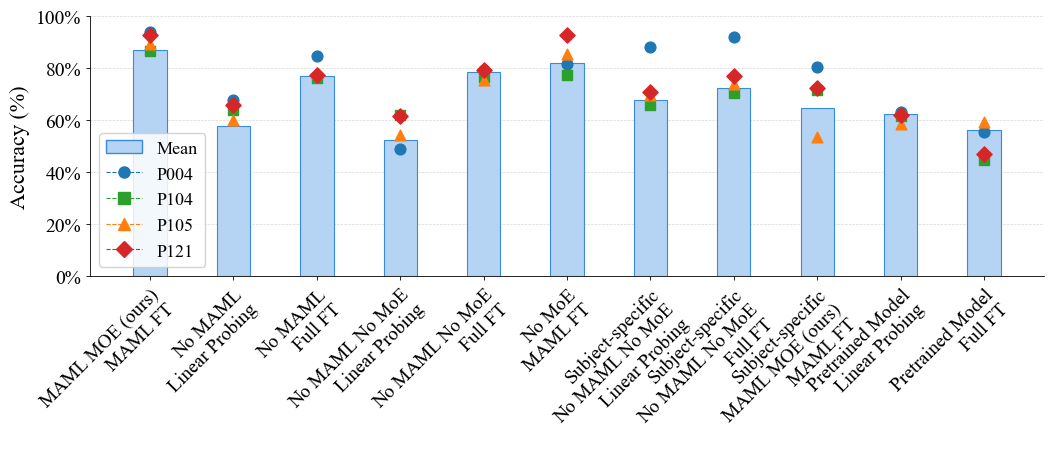

Saved fig1_main.pdf / .png


In [22]:
figure_main_ablations(df)


In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ─── shared style ────────────────────────────────────────────────────────────
SUBJECTS = ['P004', 'P104', 'P105', 'P121']
SUBJECT_COLORS = {
    'P004': '#1f77b4',
    'P104': '#2ca02c',
    'P105': '#ff7f0e',
    'P121': '#d62728',
}
SUBJECT_MARKERS = {
    'P004': 'o',
    'P104': 's',
    'P105': '^',
    'P121': 'D',
}
BAR_FACE     = '#b5d4f4'
BAR_EDGE     = '#378add'
REF_BAR_FACE = '#d3d3d3'
REF_BAR_EDGE = '#888888'
OURS_BAR_FACE = '#f4c542'
OURS_BAR_EDGE = '#c49a00'

FONT_SIZE_TICKS        = 14
FONT_SIZE_LABELS       = 16
FONT_SIZE_LEGEND       = 12
FONT_SIZE_XTICKLABELS  = 12
FONT_SIZE_GROUP_LABEL  = 16


def _apply_common_style(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, zorder=1)
    ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.set_ylabel('Accuracy (%)', fontsize=FONT_SIZE_LABELS)
    ax.tick_params(axis='both', labelsize=FONT_SIZE_TICKS)


def _subject_legend_handles(subjects):
    handles = []
    handles += [
        plt.Line2D([0], [0],
                   color=SUBJECT_COLORS[s],
                   marker=SUBJECT_MARKERS[s],
                   linestyle='--', linewidth=0.8, markersize=8, label=s)
        for s in subjects
    ]
    return handles


def _add_legend_with_backing(ax, handles, loc='lower left'):
    ax.legend(
        handles=handles,
        fontsize=FONT_SIZE_LEGEND,
        frameon=True,
        facecolor='white',
        edgecolor='#cccccc',
        framealpha=0.85,
        loc=loc,
    )


def _get_best_row(group_df, force_method=None):
    if force_method is not None:
        group_df = group_df[group_df['Finetune_Method'] == force_method]
        assert len(group_df) > 0, f"No rows with Finetune_Method='{force_method}'"
    assert len(group_df) > 0, "Empty group passed to _get_best_row"
    return group_df.loc[group_df['Mean'].idxmax()]


def _draw_group_bracket(ax, x_positions, label, bar_width, y_frac=-0.18, color="#000000"):
    x_left  = x_positions[0]  - bar_width / 2
    x_right = x_positions[-1] + bar_width / 2
    x_mid   = (x_left + x_right) / 2

    ax.annotate('',
                xy=(x_right, y_frac), xytext=(x_left, y_frac),
                xycoords=('data', 'axes fraction'),
                textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='-', color=color, lw=1.2),
                annotation_clip=False)

    ax.annotate(label,
                xy=(x_mid, y_frac - 0.04),
                xycoords=('data', 'axes fraction'),
                ha='center', va='top',
                fontsize=FONT_SIZE_GROUP_LABEL,
                color=color,
                annotation_clip=False)


def figure_main_ablations(df, save_prefix='ablations_main_result', show_lines=False):
    factorial_ids = ['A2', 'A1', 'A4', 'M0']
    reference_ids = ['A7', 'A8']
    baseline_entries = [
        ('A11', 'head',  'Linear\nProbing'),
        ('A11', 'full',  'Full\nFinetuning'),
    ]
    baseline_ids     = [e[0] for e in baseline_entries]
    baseline_methods = [e[1] for e in baseline_entries]
    baseline_labels  = [e[2] for e in baseline_entries]

    # ── Select rows ──────────────────────────────────────────────────────────
    force_method = {aid: None for aid in factorial_ids + reference_ids}
    force_method['M0'] = 'MAML'

    rows = []
    for aid in factorial_ids + reference_ids:
        group = df[df['Ablation_ID'] == aid]
        assert len(group) > 0, f"Ablation_ID '{aid}' not found in df"
        rows.append(_get_best_row(group, force_method=force_method[aid]))

    main_sub = {row['Ablation_ID']: row for row in rows}

    baseline_rows = []
    for aid, method, _ in baseline_entries:
        group = df[df['Ablation_ID'] == aid]
        assert len(group) > 0, f"Ablation_ID '{aid}' not found in df"
        baseline_rows.append(_get_best_row(group, force_method=method))

    # ── Labels ───────────────────────────────────────────────────────────────
    factorial_labels = [
        'No MAML\nNo MoE',
        'No MAML\nMoE',
        'MAML\nNo MoE',
        'MAML + MoE\n(ours)',
    ]
    reference_labels = [
        'No MAML\nNo MoE',
        'MAML + MoE',
    ]
    all_labels = factorial_labels + reference_labels + baseline_labels

    # ── x positions ──────────────────────────────────────────────────────────
    bar_width    = 0.6
    group_gap    = 0.9   # tighter gap between groups
    subj_bar_gap = 0.0   # no extra spacing between subject-specific bars

    factorial_x = np.arange(len(factorial_ids), dtype=float)

    ref_start   = factorial_x[-1] + group_gap + 1.0
    reference_x = np.array([ref_start, ref_start + 1.0 + subj_bar_gap])

    base_start  = reference_x[-1] + group_gap + 1.0
    baseline_x  = np.array([base_start + i for i in range(len(baseline_entries))], dtype=float)

    all_x = np.concatenate([factorial_x, reference_x, baseline_x])

    # ── Bar colors ───────────────────────────────────────────────────────────
    bar_faces, bar_edges = [], []
    for aid in factorial_ids:
        if aid == 'M0':
            bar_faces.append(OURS_BAR_FACE); bar_edges.append(OURS_BAR_EDGE)
        else:
            bar_faces.append(BAR_FACE);       bar_edges.append(BAR_EDGE)
    for _ in reference_ids:
        bar_faces.append(REF_BAR_FACE); bar_edges.append(REF_BAR_EDGE)
    for _ in baseline_entries:
        bar_faces.append(REF_BAR_FACE); bar_edges.append(REF_BAR_EDGE)

    # ── Combine all rows in x-order ──────────────────────────────────────────
    all_rows = [main_sub[aid] for aid in factorial_ids] \
             + [main_sub[aid] for aid in reference_ids] \
             + baseline_rows

    # ── Plot ─────────────────────────────────────────────────────────────────
    fig_width = all_x[-1] * 1.5 + 3
    fig, ax = plt.subplots(figsize=(fig_width, 5))

    for i, (row, xi) in enumerate(zip(all_rows, all_x)):
        ax.bar(xi, row['Mean'] * 100, width=bar_width,
               color=bar_faces[i], edgecolor=bar_edges[i],
               linewidth=0.8, zorder=2)
        for subj in SUBJECTS:
            ax.scatter(xi, row[subj] * 100,
                       color=SUBJECT_COLORS[subj],
                       marker=SUBJECT_MARKERS[subj],
                       s=60, zorder=4)

    # Vertical dividers between groups
    for gap_x in [(factorial_x[-1] + reference_x[0]) / 2,
                  (reference_x[-1] + baseline_x[0]) / 2]:
        ax.axvline(gap_x, color='#aaaaaa', linestyle=':', linewidth=1.0, zorder=1)

    # Group bracket labels below x-axis
    _draw_group_bracket(ax, factorial_x, 'Cross-subject Ablations',    bar_width)
    _draw_group_bracket(ax, reference_x, 'Subject-specific Baselines', bar_width)
    _draw_group_bracket(ax, baseline_x,  'Pretrained Baseline',        bar_width)

    # Axes
    ax.set_xticks(all_x)
    ax.set_xticklabels(all_labels, fontsize=FONT_SIZE_XTICKLABELS, ha='center')
    ax.set_ylim(0, 105)
    ax.set_xlim(all_x[0] - bar_width, all_x[-1] + bar_width)

    _apply_common_style(ax)
    _add_legend_with_backing(ax, _subject_legend_handles(SUBJECTS))

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.28)

    #plt.savefig(f'{save_prefix}.pdf', bbox_inches='tight')
    #plt.savefig(f'{save_prefix}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved {save_prefix}.pdf / .png')

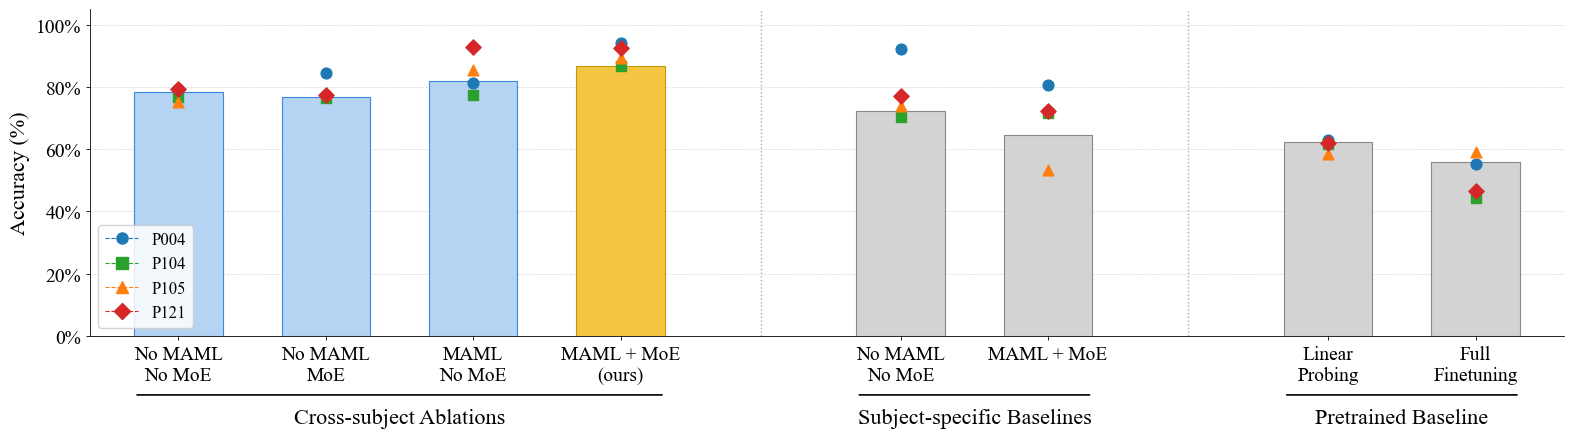

Saved ablations_main_result.pdf / .png


In [24]:
figure_main_ablations(df)

In [25]:
def figure_num_experts(df, save_prefix='fig2_experts', show_lines=False, y_min=None, legend_loc='lower left'):
    sub = df[df['Ablation_ID'].str.startswith('A5')].copy()

    def extract_experts(ablation_id):
        m = re.search(r'E(\d+)', ablation_id)
        assert m, f"Could not parse expert count from Ablation_ID: '{ablation_id}'"
        return int(m.group(1))

    sub['n_experts'] = sub['Ablation_ID'].apply(extract_experts)
    sub = sub.sort_values('n_experts')

    n = len(sub)
    bar_width = 0.4
    x = np.arange(n)

    fig, ax = plt.subplots(figsize=(max(5, n * 1.0), 5))

    ax.bar(x, sub['Mean'] * 100, width=bar_width,
           color=BAR_FACE, edgecolor=BAR_EDGE, linewidth=0.8, zorder=2)

    for subj in SUBJECTS:
        ys = sub[subj] * 100
        if show_lines:
            ax.plot(x, ys, color=SUBJECT_COLORS[subj], linestyle='--',
                    linewidth=0.8, alpha=0.5, zorder=3)
        ax.scatter(x, ys, color=SUBJECT_COLORS[subj],
                   marker=SUBJECT_MARKERS[subj], s=60, zorder=4, label=subj)

    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in sub['n_experts'].tolist()], fontsize=FONT_SIZE_XTICKLABELS)

    if y_min is None:
        ax.set_ylim(0, 100)
    else:
        if y_min == 'auto':
            all_vals = pd.concat([sub[s] * 100 for s in SUBJECTS])
            y_min = all_vals.min() * 0.75
        ax.set_ylim(y_min, 100)

    ax.set_xlabel('Number of Experts', fontsize=FONT_SIZE_LABELS, labelpad=12)
    _apply_common_style(ax)
    _add_legend_with_backing(ax, _subject_legend_handles(SUBJECTS), loc=legend_loc)

    plt.tight_layout()
    #plt.savefig(f'{save_prefix}.pdf', bbox_inches='tight')
    #plt.savefig(f'{save_prefix}.png', bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved {save_prefix}.pdf / .png')

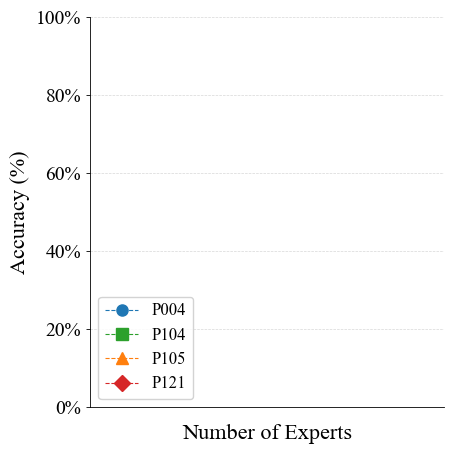

Saved fig2_experts.pdf / .png


In [26]:
figure_num_experts(df)


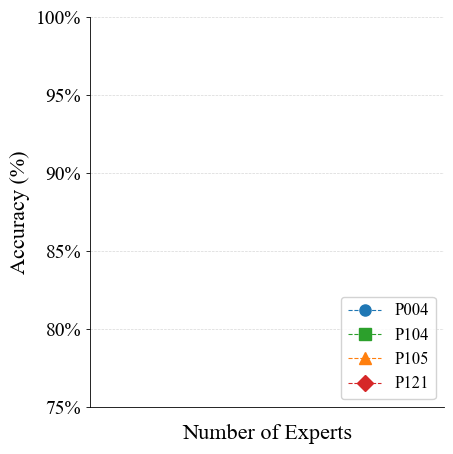

Saved fig2_experts.pdf / .png


In [27]:
figure_num_experts(df, y_min=75.0, legend_loc='lower right')